# Power Spread Event Decision Framework

This notebook studies how real-time power prices correct day-ahead expectations using public CAISO OASIS data.

The structure follows a market-first workflow:

1. Select data for a clear market reason.
2. Define the spread and component math.
3. Diagnose large events before modeling.
4. Build simple features and compare models.
5. Interpret results as a decision screen.


## Data Selection

The default data is CAISO OASIS for `TH_NP15_GEN-APND`, calendar year 2024.

This data is selected because it is public, reproducible, matched across day-ahead and real-time markets, and includes energy/congestion/loss components. That component detail is important because a large DA/RT spread is only useful if we can explain what drove it.


## Market Math

The core target is:

$$\text{Spread}_t = \text{RT LMP}_t - \text{DA LMP}_t$$

Interpretation:

$$\text{Spread}_t \approx \text{Realized System Stress}_t - \text{Expected System Stress}_t$$

LMP decomposes into:

$$\text{LMP} = \text{Energy} + \text{Congestion} + \text{Loss}$$

Therefore:

$$\text{RT LMP} - \text{DA LMP} = \Delta \text{Energy} + \Delta \text{Congestion} + \Delta \text{Loss}$$


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from caiso_fetch import load_or_fetch_caiso
from event_analysis import add_event_metrics, event_summary, top_events
from features import FEATURE_COLUMNS, build_feature_frame
from modeling import signal_summary, walk_forward_backtest

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (11, 6), 'axes.spines.top': False, 'axes.spines.right': False})


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
DATA_PATH = ROOT / 'data' / 'raw' / 'caiso_th_np15_da_rt_2024.csv'
raw = load_or_fetch_caiso(DATA_PATH)
events = add_event_metrics(raw)
print(f'Rows: {len(raw):,}')
print(f"Date range: {raw['datetime_utc'].min()} to {raw['datetime_utc'].max()}")
raw.head()


Rows: 8,784
Date range: 2024-01-01 08:00:00+00:00 to 2025-01-01 07:00:00+00:00


,datetime_utc,node,total_lmp_da,system_energy_price_da,congestion_price_da,marginal_loss_price_da,total_lmp_rt,system_energy_price_rt,congestion_price_rt,marginal_loss_price_rt,datetime_local,spread,energy_spread,congestion_spread,loss_spread
0,2024-01-01 08:00:00+00:00,TH_NP15_GEN-APND,46.75774,47.42616,0.01926,-0.68768,46.619320,46.282396,0.701595,-0.364671,2024-01-01 00:00:00,-0.138420,-1.143764,0.682335,0.323009
1,2024-01-01 09:00:00+00:00,TH_NP15_GEN-APND,46.04052,46.65594,0.01443,-0.62986,46.142559,45.330707,0.708820,0.103033,2024-01-01 01:00:00,0.102039,-1.325233,0.694390,0.732893
2,2024-01-01 10:00:00+00:00,TH_NP15_GEN-APND,45.13062,46.02649,0.01546,-0.91132,46.208948,45.546664,0.714809,-0.052518,2024-01-01 02:00:00,1.078328,-0.479826,0.699349,0.858803
3,2024-01-01 11:00:00+00:00,TH_NP15_GEN-APND,44.93121,45.70215,0.01513,-0.78608,45.490762,44.834313,0.538956,0.117491,2024-01-01 03:00:00,0.559552,-0.867838,0.523826,0.903571
4,2024-01-01 12:00:00+00:00,TH_NP15_GEN-APND,44.55260,45.30814,0.05547,-0.81102,44.062200,43.393207,0.535928,0.133063,2024-01-01 04:00:00,-0.490400,-1.914933,0.480457,0.944083


## Broad DA/RT Context

A raw hourly chart can be dominated by a handful of extreme events. The first visual therefore uses a 7-day rolling daily average to show the broad relationship before zooming into events.


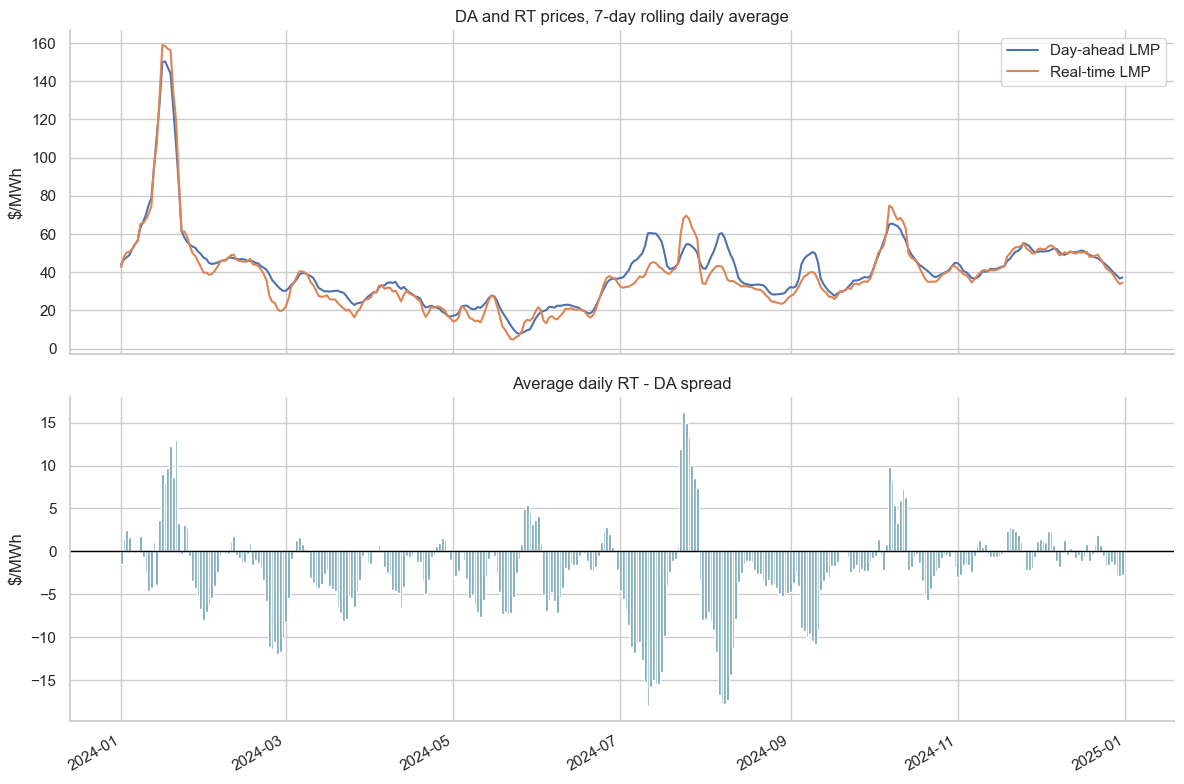

In [3]:
daily = (
    raw.set_index('datetime_local')[['total_lmp_da', 'total_lmp_rt', 'spread']]
    .resample('D').mean().rolling(7, min_periods=1).mean().reset_index()
)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily['datetime_local'], daily['total_lmp_da'], label='Day-ahead LMP')
axes[0].plot(daily['datetime_local'], daily['total_lmp_rt'], label='Real-time LMP')
axes[0].set_title('DA and RT prices, 7-day rolling daily average')
axes[0].set_ylabel('$/MWh')
axes[0].legend()
axes[1].bar(daily['datetime_local'], daily['spread'], color='#6a9fb5', width=1.0)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Average daily RT - DA spread')
axes[1].set_ylabel('$/MWh')
fig.autofmt_xdate()
plt.tight_layout()


## Event Diagnosis

Large spreads are evaluated by size, abnormality, and component driver. This separates energy-led events from congestion-led events.


,datetime_local,total_lmp_da,total_lmp_rt,spread,energy_spread,congestion_spread,loss_spread,spread_zscore_168h,driver
0,2024-01-15 09:00:00,180.67896,1217.441608,1036.762648,616.817774,407.835851,12.109042,15.907954,mixed
1,2024-07-23 19:00:00,292.00266,933.957401,641.954741,641.374225,8.422558,-7.842050,13.943388,energy_led
2,2024-01-15 08:00:00,213.40349,850.046918,636.643428,428.152764,196.642199,11.848467,15.153618,energy_led
3,2024-10-07 19:00:00,119.12537,687.705182,568.579812,246.293099,320.914874,1.371834,18.255168,mixed
4,2024-07-23 18:00:00,142.81639,693.410095,550.593705,542.244137,19.516599,-11.167029,31.867272,energy_led
5,2024-01-16 09:00:00,229.05235,709.352838,480.300488,286.035843,193.470207,0.794433,4.393646,mixed
6,2024-01-15 10:00:00,182.12907,564.772189,382.643119,233.773192,145.753695,3.116213,3.671682,energy_led
7,2024-01-13 10:00:00,181.77000,520.896400,339.126400,447.769743,-109.943816,1.300459,18.250542,energy_led
8,2024-01-13 11:00:00,175.56563,473.741252,298.175622,467.705576,-168.791929,-0.738006,9.241374,energy_led
9,2024-05-27 19:00:00,43.18118,340.800794,297.619614,311.306961,-1.102871,-12.584486,22.593876,energy_led


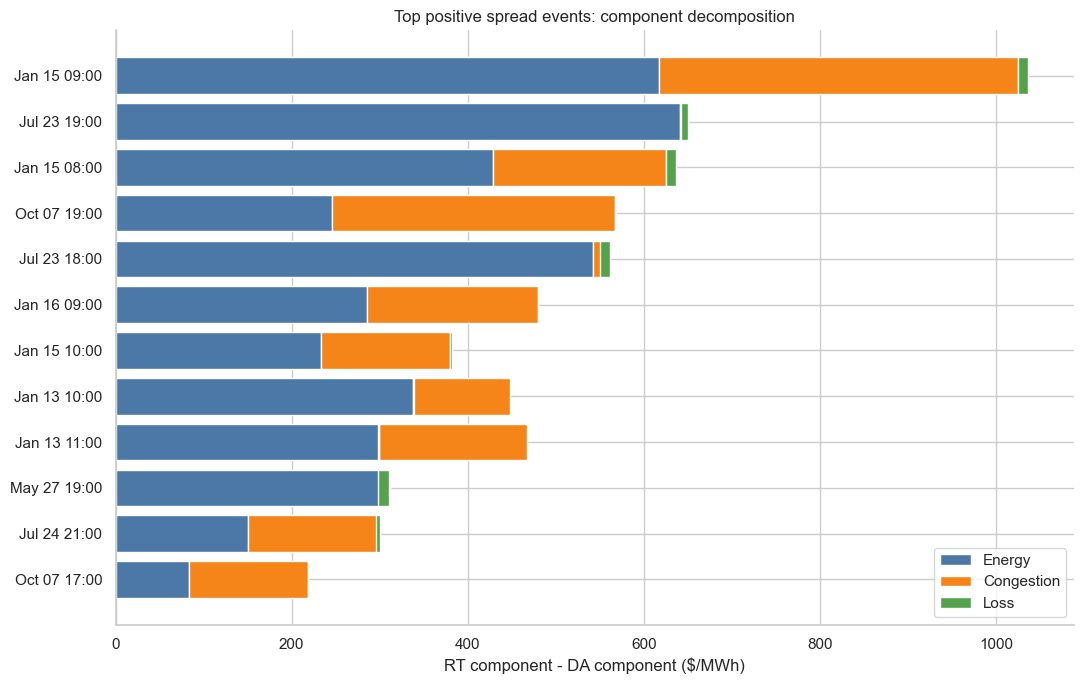

In [4]:
top = top_events(events, n=12).sort_values('spread')
labels = top['datetime_local'].dt.strftime('%b %d %H:%M')
fig, ax = plt.subplots(figsize=(11, 7))
left = pd.Series(0.0, index=top.index)
for col, label, color in [('energy_spread', 'Energy', '#4c78a8'), ('congestion_spread', 'Congestion', '#f58518'), ('loss_spread', 'Loss', '#54a24b')]:
    ax.barh(labels, top[col], left=left, label=label, color=color)
    left = left + top[col]
ax.set_title('Top positive spread events: component decomposition')
ax.set_xlabel('RT component - DA component ($/MWh)')
ax.legend()
plt.tight_layout()
top_events(events, n=10)


## Calendar And Regime Structure

Power prices are seasonal and intraday. Before using a model, we check whether spreads differ by hour and weekday.


Text(79.75, 0.5, 'Hour')

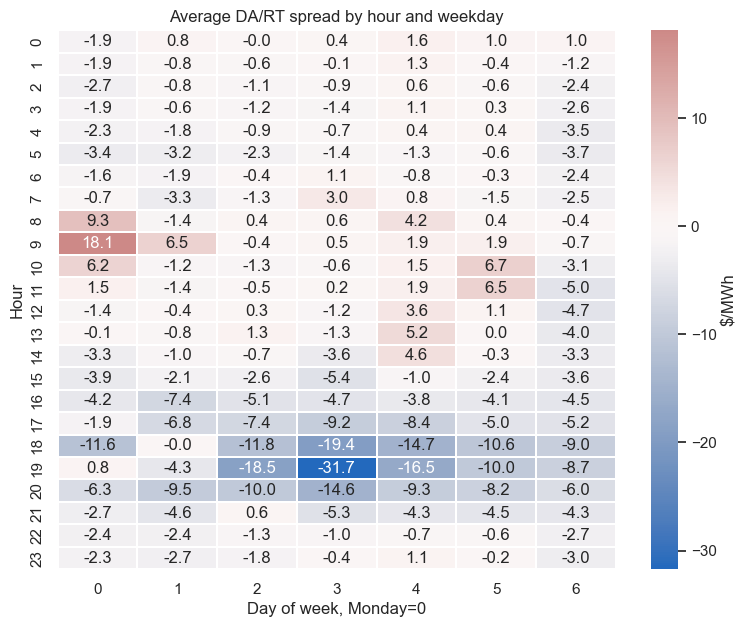

In [5]:
frame = build_feature_frame(events)
pivot = frame.pivot_table(index='hour', columns='day_of_week', values='spread', aggfunc='mean')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot, cmap='vlag', center=0, annot=True, fmt='.1f', linewidths=0.3, cbar_kws={'label': '$/MWh'}, ax=ax)
ax.set_title('Average DA/RT spread by hour and weekday')
ax.set_xlabel('Day of week, Monday=0')
ax.set_ylabel('Hour')


## Model Validation

The model sequence is conservative: hourly baseline, Ridge regression, then Random Forest. The objective is to test whether engineered features add information beyond simple delivery-hour structure.


In [6]:
predictions, metrics, importances = walk_forward_backtest(frame, FEATURE_COLUMNS)
metric_summary = metrics.groupby('model', as_index=False).mean(numeric_only=True)
metric_summary[['model', 'mae', 'rmse', 'bias', 'directional_accuracy']]


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/shubhamnanewar/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,model,mae,rmse,bias,directional_accuracy
0,hourly_baseline,9.232695,23.011104,-0.137793,0.601389
1,random_forest,8.516783,20.214568,1.159407,0.666204
2,ridge,8.553997,20.549053,0.169003,0.652315


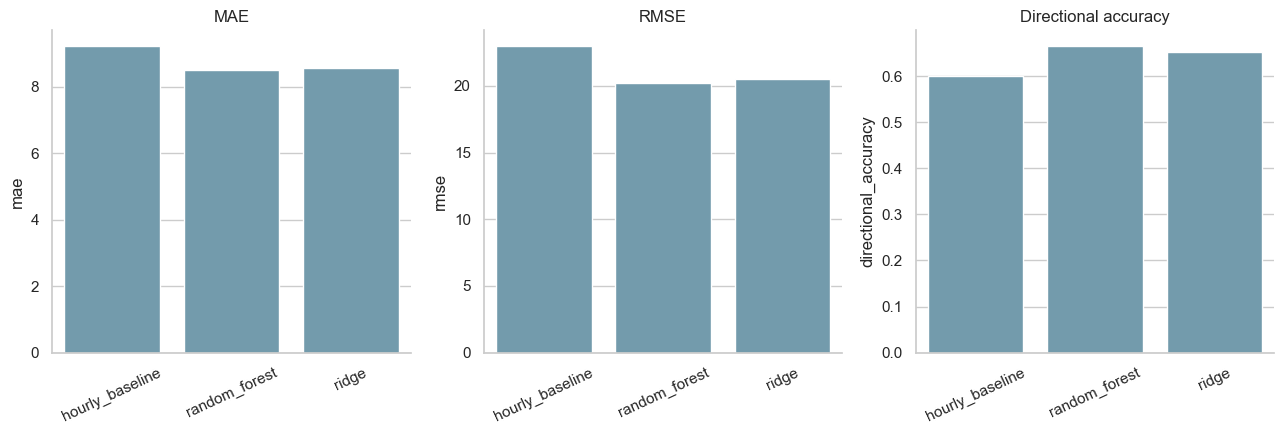

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, metric, title in zip(axes, ['mae', 'rmse', 'directional_accuracy'], ['MAE', 'RMSE', 'Directional accuracy']):
    sns.barplot(data=metric_summary, x='model', y=metric, color='#6a9fb5', ax=ax)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=25)
    ax.set_xlabel('')
plt.tight_layout()


## Decision Screen

The final output is not a direct trade recommendation. It is a research screen. A stronger candidate hour has abnormal spread behavior, interpretable component drivers, supportive recent regime behavior, and a high model ranking.


In [8]:
signal_summary(predictions)


{'signal_count': 432.0,
 'signal_share_of_hours': 0.1,
 'mean_realized_spread_signal_hours': 10.35758632330247,
 'median_realized_spread_signal_hours': 3.0993287500000015,
 'positive_hit_rate_signal_hours': 0.6736111111111112,
 'positive_hit_rate_all_hours': 0.3988425925925926,
 'share_of_total_positive_spread_captured': 0.4119377170840084}

## How To Interpret The Story

A useful result is not that every hourly price is forecast exactly. Real-time power prices can move because of operational surprises. A useful result is that the model ranks higher-risk hours better than a simple baseline and that the largest spread events can be explained through energy or congestion components.

The practical interpretation is:

- use component decomposition to understand why an event happened,
- use calendar and rolling features to understand whether spread risk clusters,
- use model metrics to check whether features add signal,
- use top-decile ranking as a decision screen for deeper market review.
